In [1]:
import numpy as np
import matplotlib.pyplot as plt
from dataclasses import dataclass
import time

# Import your newly finished class!
from model.drs_model import DRSModel


@dataclass
class MiningParameters:
    parameter_OreToBeExtractedDuringWarmingPeriod: float = 600000.0
    parameter_TotalOreToBeExtracted: float = 6600000.0
    parameter_DurationOfProductionCampaigns: float = 34.0
    parameter_DurationOfShutdowns: float = 1.0
    parameter_ModeAOre1MillingRate: float = 3600.0
    parameter_ModeAOre2MillingRate: float = 2400.0
    parameter_ModeAContingencyOre1MillingRate: float = 3900.0
    parameter_ModeBOre1MillingRate: float = 4600.0
    parameter_ModeBOre2MillingRate: float = 800.0
    parameter_ModeBContingencyOre2MillingRate: float = 2500.0
    parameterVector_GeostatisticalModelParameters: tuple = (
        30000.0,
        50000.0,
        30.0,
        30.0,
        5.0,
        1.0,
    )
    controlVariable_CriticalOre2Level: float = 20400.0
    controlVariable_TargetOreStockLevel: float = 60000.0
    controlVariable_DurationOfContingencySegments: float = 1.0
    parameter_ExtractionGain: float = 0.02  # Reacts to 2% of the error
    parameter_MaxExtraction: float = 7200.0
    parameter_MinExtraction: float = 1000.0
    controlVariable_StockUpperLimit: float = 70000.0
    controlVariable_StockLowerLimit: float = 50000.0


mining_params = MiningParameters()

In [2]:
# Constants for easier reading
total_mill_A = "(parameter_ModeAOre1MillingRate + parameter_ModeAOre2MillingRate)"
total_mill_B = "(parameter_ModeBOre1MillingRate + parameter_ModeBOre2MillingRate)"

# Dynamic Extraction Logic (Proportional Controller)
# Mine now targets the TOTAL milling rate + corrective gain
extraction_A_expr = f"max(parameter_MinExtraction, min(parameter_MaxExtraction, {total_mill_A} + (controlVariable_TargetOreStockLevel - OreStock_Level) * parameter_ExtractionGain))"

arena_config = {
    # 1. Reliable Termination (Doesn't wait for a 0.001 error coincidence)
    "confExString_TerminatingCondition": "OreExtraction_Level >= parameter_TotalOreToBeExtracted",
    "confExString_InitialRateConfigurationNumber": "1",
    # 1D Vectors Initial Conditions
    "confExString_InitialLevelValue": ["0", "0", "60000", "42000", "18000"],
    "confExString_InitialTimerValue": ["0"] * 9,
    "confExString_InitialDiscretelyDynamicalNumericalVariableValue": [
        "40000",
        "30",
        "1",
    ],
    "confExString_InitialCategoricalVariableValue": [""],
    # 2. LEVEL RATES (5 Levels x 7 Configs)
    "confExString_LevelRate": [
        # Level 0: Mine Total Extraction (Linked to total mill rate A)
        [
            extraction_A_expr,
            "parameter_ModeAContingencyOre1MillingRate",
            "parameter_ModeAOre1MillingRate*100/(100-PercentageOfOre2InCurrentParcel)",
            total_mill_B,
            "parameter_ModeBContingencyOre2MillingRate",
            "parameter_ModeBOre2MillingRate*100/PercentageOfOre2InCurrentParcel",
            "0",
        ],
        # Level 1: Current Parcel Progress (Matches Level 0)
        [
            extraction_A_expr,
            "parameter_ModeAContingencyOre1MillingRate",
            "parameter_ModeAOre1MillingRate*100/(100-PercentageOfOre2InCurrentParcel)",
            total_mill_B,
            "parameter_ModeBContingencyOre2MillingRate",
            "parameter_ModeBOre2MillingRate*100/PercentageOfOre2InCurrentParcel",
            "0",
        ],
        # Level 2: Stockpile Level (Net Flow = Extraction - Milling)
        [
            f"{extraction_A_expr} - {total_mill_A}",
            f"parameter_ModeAContingencyOre1MillingRate - {total_mill_A}",
            f"(parameter_ModeAOre1MillingRate*100/(100-PercentageOfOre2InCurrentParcel)) - {total_mill_A}",
            "0",  # Config 4 (Normal B) is perfectly balanced
            f"parameter_ModeBContingencyOre2MillingRate - {total_mill_B}",
            f"(parameter_ModeBOre2MillingRate*100/PercentageOfOre2InCurrentParcel) - {total_mill_B}",
            "0",
        ],
        # Level 3: Ore 1 Inventory
        [
            f"{total_mill_A}*(1-PercentageOfOre2InCurrentParcel/100)-parameter_ModeAOre1MillingRate",
            "parameter_ModeAContingencyOre1MillingRate*(1-PercentageOfOre2InCurrentParcel/100)-parameter_ModeAContingencyOre1MillingRate",
            "0",
            f"{total_mill_B}*(100-PercentageOfOre2InCurrentParcel)/100 - parameter_ModeBOre1MillingRate",
            "parameter_ModeBContingencyOre2MillingRate*(100-PercentageOfOre2InCurrentParcel)/100",
            "parameter_ModeBOre2MillingRate*(100-PercentageOfOre2InCurrentParcel)/(PercentageOfOre2InCurrentParcel)-parameter_ModeBOre1MillingRate",
            "0",
        ],
        # Level 4: Ore 2 Inventory
        [
            f"{total_mill_A}*(PercentageOfOre2InCurrentParcel/100)-parameter_ModeAOre2MillingRate",
            f"parameter_ModeAContingencyOre1MillingRate*(PercentageOfOre2InCurrentParcel/100)",
            f"parameter_ModeAOre1MillingRate*PercentageOfOre2InCurrentParcel/(100-PercentageOfOre2InCurrentParcel)-parameter_ModeAOre2MillingRate",
            f"{total_mill_B}*PercentageOfOre2InCurrentParcel/100 - parameter_ModeBOre2MillingRate",
            f"parameter_ModeBContingencyOre2MillingRate*PercentageOfOre2InCurrentParcel/100 - parameter_ModeBContingencyOre2MillingRate",
            "0",
            "0",
        ],
    ],
    # 3. THRESHOLDS & HYSTERESIS
    "confExString_LowerLevelThreshold": [
        ["-999999"] * 7,
        ["-999999"] * 7,
        [
            "-999999",
            "-999999",
            "controlVariable_StockLowerLimit",
            "-999999",
            "-999999",
            "controlVariable_StockLowerLimit",
            "-999999",
        ],
        ["0", "0", "-999999", "0", "-999999", "-999999", "-999999"],
        ["0", "-999999", "-999999", "0", "0", "-999999", "-999999"],
    ],
    "confExString_UpperLevelThreshold": [
        ["parameter_TotalOreToBeExtracted"] * 7,
        ["MassOfCurrentParcel"] * 6 + ["999999"],
        ["controlVariable_StockUpperLimit"] * 7,
        ["999999"] * 7,
        ["999999"] * 7,
    ],
    # RESULTANT STATES
    "confExString_LowerLevelResultantRateConfiguration": [
        ["0"] * 7,
        ["0"] * 7,
        ["0", "0", "1", "0", "0", "4", "0"],
        ["3", "3", "0", "5", "0", "0", "0"],
        ["2", "0", "0", "6", "6", "0", "0"],
    ],
    "confExString_UpperLevelResultantRateConfiguration": [
        ["1", "2", "3", "4", "5", "6", "0"],
        ["1", "2", "3", "4", "5", "6", "0"],
        ["0", "0", "7", "0", "0", "7", "0"],
        ["0"] * 7,
        ["0"] * 7,
    ],
    "confExString_LowerLevelAssignmentAddress": [["0"] * 7 for _ in range(5)],
    "confExString_UpperLevelAssignmentAddress": [
        ["0"] * 7,
        ["0"] * 6 + ["0"],
        ["2"] * 7,
        ["0"] * 7,
        ["0"] * 7,
    ],
    # TIMER ENGINE
    "confExString_TimerRate": [
        ["1"] * 7,
        ["0", "1", "0", "0", "1", "0", "0"],
        ["1", "0", "0", "0", "0", "0", "0"],
        ["0", "1", "0", "0", "0", "0", "0"],
        ["0", "0", "1", "0", "0", "0", "0"],
        ["0", "0", "0", "1", "0", "0", "0"],
        ["0", "0", "0", "0", "1", "0", "0"],
        ["0", "0", "0", "0", "0", "1", "0"],
        ["0", "0", "0", "0", "0", "0", "1"],
    ],
    "confExString_LowerTimerThreshold": [["-999999"] * 7 for _ in range(9)],
    "confExString_UpperTimerThreshold": [
        ["parameter_DurationOfProductionCampaigns"] * 6
        + ["parameter_DurationOfShutdowns"],
        [
            "999999",
            "controlVariable_DurationOfContingencySegments",
            "999999",
            "999999",
            "controlVariable_DurationOfContingencySegments",
            "999999",
            "999999",
        ],
        ["999999"] * 7,
        ["999999"] * 7,
        ["999999"] * 7,
        ["999999"] * 7,
        ["999999"] * 7,
        ["999999"] * 7,
        ["999999"] * 7,
    ],
    "confExString_UpperTimerResultantRateConfiguration": [
        [
            "7",
            "7",
            "7",
            "7",
            "7",
            "7",
            "(Ore2Stock_Level>controlVariable_CriticalOre2Level)*(OreStock_Level<=controlVariable_StockUpperLimit)*1+(Ore2Stock_Level>controlVariable_CriticalOre2Level)*(OreStock_Level>controlVariable_StockUpperLimit)*3+(Ore2Stock_Level<=controlVariable_CriticalOre2Level)*(OreStock_Level<=controlVariable_StockUpperLimit)*4+(Ore2Stock_Level<=controlVariable_CriticalOre2Level)*(OreStock_Level>controlVariable_StockUpperLimit)*6",
        ],
        ["0", "1", "0", "0", "4", "0", "0"],
        ["0"] * 7,
        ["0"] * 7,
        ["0"] * 7,
        ["0"] * 7,
        ["0"] * 7,
        ["0"] * 7,
        ["0"] * 7,
    ],
    "confExString_UpperTimerAssignmentAddress": [
        ["2"] * 7,
        ["0"] * 7,
        ["0"] * 7,
        ["0"] * 7,
        ["0"] * 7,
        ["0"] * 7,
        ["0"] * 7,
        ["0"] * 7,
        ["0"] * 7,
    ],
    "confExString_LowerTimerAssignmentAddress": [["0"] * 7 for _ in range(9)],
    # ASSIGNMENT LOGIC (For resetting levels/timers and selecting parcels)
    "confExString_AssignmentSequence": [
        ["T003:0", "T004:0", "T005:0", "T006:0", "T007:0", "T008:0", "T009:0"],  # Reset
        ["T001:0", "", "", "", "", "", ""],  # Campaign reset
        ["T002:0", "", "", "", "", "", ""],  # Shutdown reset
        [
            "L002:0",
            "N001:UNIF(parameterVector_GeostatisticalModelParameters(1),parameterVector_GeostatisticalModelParameters(2))",
            "N002:MX(NORM(parameterVector_GeostatisticalModelParameters(4),parameterVector_GeostatisticalModelParameters(5)),0)",
            "N003:(UNIF(0,1)<= parameterVector_GeostatisticalModelParameters(3))",
            "E001:1",
            "",
            "",
        ],
        [
            "L002:0",
            "N001:UNIF(parameterVector_GeostatisticalModelParameters(1),parameterVector_GeostatisticalModelParameters(2))",
            "N002:parameterVector_GeostatisticalModelParameters(4)",
            "N003:(UNIF(0,1)<= parameterVector_GeostatisticalModelParameters(3))",
            "E001:1",
            "",
            "",
        ],
        [
            "L002:0",
            "N001:UNIF(parameterVector_GeostatisticalModelParameters(1),parameterVector_GeostatisticalModelParameters(2))",
            "N002:MX(PercentageOfOre2InCurrentParcel + parameterVector_GeostatisticalModelParameters(6)*UNIF(-1,1),0)",
            "N003:(UNIF(0,1)<= parameterVector_GeostatisticalModelParameters(3))",
            "E001:1",
            "",
            "",
        ],
    ],
}

Initializing Framework...
Starting simulation loop...
Simulation terminated successfully at TNOW: 1180.60 days.
Execution Time: 0.1209 seconds.

--- Final Simulation Statistics ---
Total Throughput:             50.82 t/day
Time in Mode A:               56.71%
Time in Mode B:               40.32%
Time in Shutdown:             2.80%
Time in Mode A Contingency:   0.17%
Time in Mode B Contingency:   0.00%
-----------------------------------


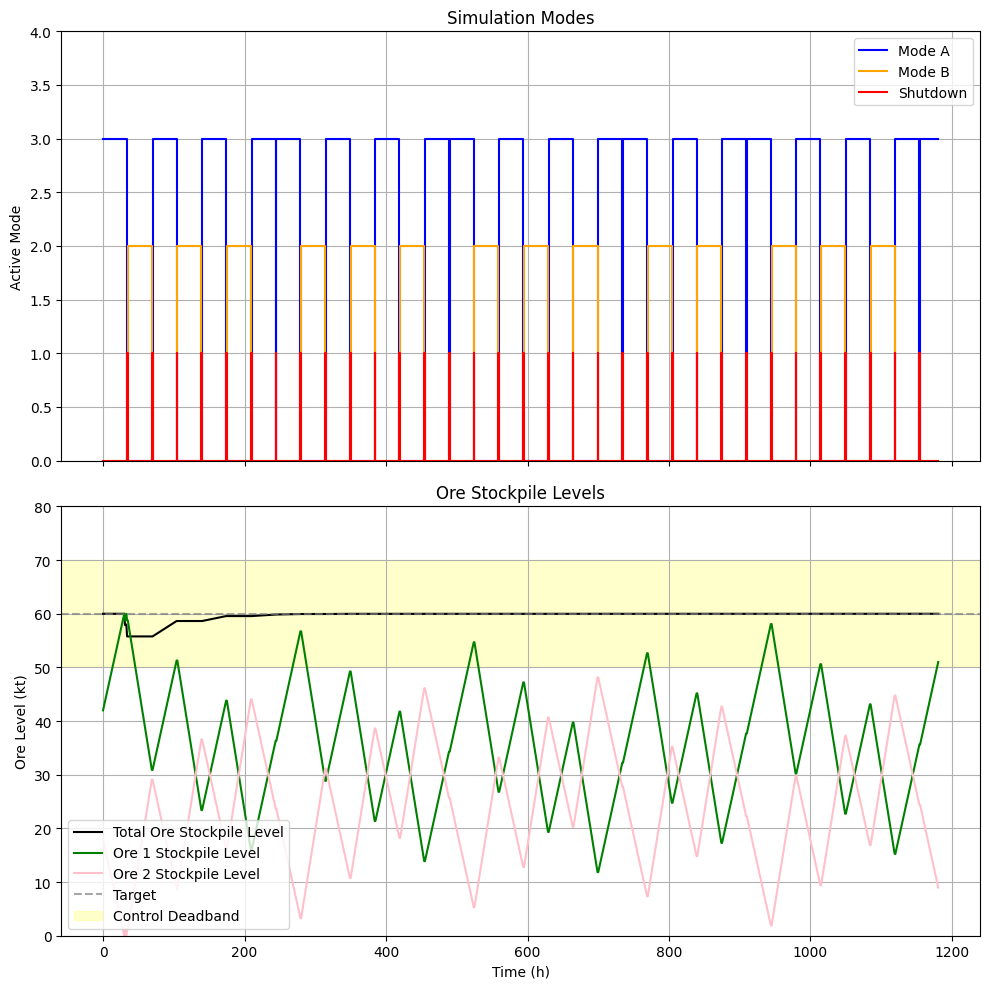

In [3]:
# Initialize Engine with decoupled parameters
print("Initializing Framework...")
model = DRSModel(parameters=mining_params)
model.load_configuration(arena_config)

# Run Simulation
print("Starting simulation loop...")
start_time = time.time()
model.run()
execution_time = time.time() - start_time

print(f"Simulation terminated successfully at TNOW: {model.TNOW:.2f} days.")
print(f"Execution Time: {execution_time:.4f} seconds.\n")

# Calculate Outputs
stats = model.calculate_statistics()
print("--- Final Simulation Statistics ---")
print(f"Total Throughput:             {stats.Throughput:,.2f} t/day")
print(f"Time in Mode A:               {stats.PortionOfTimeInModeA * 100:.2f}%")
print(f"Time in Mode B:               {stats.PortionOfTimeInModeB * 100:.2f}%")
print(f"Time in Shutdown:             {stats.PortionOfTimeInShutdown * 100:.2f}%")
print(
    f"Time in Mode A Contingency:   {stats.PortionOfTimeInModeAContingency * 100:.2f}%"
)
print(
    f"Time in Mode B Contingency:   {stats.PortionOfTimeInModeBContingency * 100:.2f}%"
)
print("-----------------------------------")

# Render Plots
model.plot_results()

In [4]:
import numpy as np
import pandas as pd
import itertools
from IPython.display import display, clear_output
import time


def run_parameter_sweep(
    gain, upper_limit, lower_limit, config_dict, num_replications=3
):
    # Initialize parameters
    params = MiningParameters()
    params.enable_feed_control = True  # We leave this ON for maximum potential yield

    # Inject the sweep variables
    params.parameter_ExtractionGain = gain
    params.controlVariable_StockUpperLimit = upper_limit
    params.controlVariable_StockLowerLimit = lower_limit

    # Run the simulation
    model = DRSModel(parameters=params)
    model.load_configuration(config_dict)

    throughputs = []
    switches_list = []
    shutdowns = []

    # Run the same configuration multiple times to find its AVERAGE performance
    for replication_seed in range(num_replications):
        model = DRSModel(parameters=params)
        model.load_configuration(config_dict)

        # Use a different, but consistent seed for each replication
        np.random.seed(replication_seed)

        model.run()

        # Calculate stats for this specific run
        rate_history = np.array(model.history_rate_config)
        switches_list.append(np.sum(np.diff(rate_history) != 0))

        stats = model.calculate_statistics()
        throughputs.append(stats.Throughput)
        shutdowns.append(stats.PortionOfTimeInShutdown * 100)

    # Return the averages across all replications
    return {
        "Gain": gain,
        "Upper Limit": upper_limit,
        "Lower Limit": lower_limit,
        "Throughput": round(np.mean(throughputs), 2),
        "Switches": int(np.mean(switches_list)),
        "Shutdown %": round(np.mean(shutdowns), 2),
    }

In [5]:
# 1. Define the Parameter Space
# We want to test soft vs aggressive gains, and narrow vs wide deadbands
gains = [0.01, 0.03, 0.05, 0.08]
upper_limits = [62000.0, 65000.0, 70000.0, 75000.0]
lower_limits = [45000.0, 50000.0, 55000.0, 58000.0]

# Calculate total combinations
combinations = list(itertools.product(gains, upper_limits, lower_limits))
total_runs = len(combinations)

print(f"Starting Hyperparameter Sweep: {total_runs} combinations...")
start_time = time.time()

sweep_results = []
count = 0

# 2. Execute the Grid Search
for gain, upper, lower in combinations:
    # Skip illogical combinations (where lower limit is higher than upper limit)
    if lower >= upper:
        continue

    result = run_parameter_sweep(gain, upper, lower, arena_config)
    if result:
        sweep_results.append(result)

    count += 1
    if count % 10 == 0:
        print(f"Completed {count}/{total_runs} runs...")

# 3. Convert to DataFrame
df_sweep = pd.DataFrame(sweep_results)
print(f"\nSweep completed in {time.time() - start_time:.2f} seconds.")

Starting Hyperparameter Sweep: 64 combinations...
Completed 10/64 runs...
Completed 20/64 runs...
Completed 30/64 runs...
Completed 40/64 runs...
Completed 50/64 runs...
Completed 60/64 runs...

Sweep completed in 23.68 seconds.


In [6]:
# 1. Define your priorities (Weights should sum to 1.0)
WEIGHT_THROUGHPUT = 0.50  # 50% Importance (Economics)
WEIGHT_SWITCHES = 0.35  # 35% Importance (Equipment Health)
WEIGHT_SHUTDOWN = 0.15  # 15% Importance (Uptime)

df_scored = df_sweep.copy()

# 2. Normalize the data (Scale everything from 0 to 1)
# For Throughput: Higher is better
min_t, max_t = df_scored["Throughput"].min(), df_scored["Throughput"].max()
if max_t == min_t:
    df_scored["Norm_Throughput"] = 1.0
else:
    df_scored["Norm_Throughput"] = (df_scored["Throughput"] - min_t) / (max_t - min_t)

# For Switches: Lower is better (so we invert it: max - x)
min_s, max_s = df_scored["Switches"].min(), df_scored["Switches"].max()
if max_s == min_s:
    df_scored["Norm_Switches"] = 1.0
else:
    df_scored["Norm_Switches"] = (max_s - df_scored["Switches"]) / (max_s - min_s)

# For Shutdown: Lower is better
min_sh, max_sh = df_scored["Shutdown %"].min(), df_scored["Shutdown %"].max()
if max_sh == min_sh:
    df_scored["Norm_Shutdown"] = 1.0
else:
    df_scored["Norm_Shutdown"] = (max_sh - df_scored["Shutdown %"]) / (max_sh - min_sh)

# 3. Calculate the Composite Fitness Score
df_scored["Fitness Score"] = (
    (df_scored["Norm_Throughput"] * WEIGHT_THROUGHPUT)
    + (df_scored["Norm_Switches"] * WEIGHT_SWITCHES)
    + (df_scored["Norm_Shutdown"] * WEIGHT_SHUTDOWN)
)

# 4. Sort by the highest score to find the mathematically perfect configuration
best_configs = df_scored.sort_values(by="Fitness Score", ascending=False).reset_index(
    drop=True
)

print("Top 3 Optimal Configurations based on your Weights:")
display(
    best_configs[
        [
            "Gain",
            "Upper Limit",
            "Lower Limit",
            "Throughput",
            "Switches",
            "Shutdown %",
            "Fitness Score",
        ]
    ].head(30)
)

Top 3 Optimal Configurations based on your Weights:


,Gain,Upper Limit,Lower Limit,Throughput,Switches,Shutdown %,Fitness Score
0,0.08,65000.0,58000.0,51.21,61,2.22,0.979851
1,0.08,65000.0,45000.0,51.21,61,2.22,0.979851
2,0.08,65000.0,55000.0,51.21,61,2.22,0.979851
3,0.08,65000.0,50000.0,51.21,61,2.22,0.979851
4,0.08,70000.0,58000.0,51.15,61,2.13,0.923077
5,0.08,70000.0,55000.0,51.15,61,2.13,0.923077
6,0.08,70000.0,50000.0,51.15,61,2.13,0.923077
7,0.08,70000.0,45000.0,51.15,61,2.13,0.923077
8,0.08,62000.0,45000.0,51.20,64,2.30,0.817870
9,0.08,62000.0,50000.0,51.20,64,2.30,0.817870


In [11]:
import numpy as np
import pandas as pd
from model.drs_model import DRSModel
import itertools


def run_ablation_trial(
    use_feed_control: bool,
    use_adaptive: bool,
    use_hysteresis: bool,
    config_dict: dict,
    num_replications: int = 3,  # Default to 5 Monte Carlo passes
):
    # 1. Define the baseline parameters
    params = MiningParameters()

    # 2. Apply Ablation Logic (Parameter Nullification)
    params.enable_feed_control = use_feed_control

    if use_adaptive:
        params.parameter_ExtractionGain = 0.08
        params.parameter_MaxExtraction = 7200.0
        params.parameter_MinExtraction = 1000.0
    else:
        params.parameter_ExtractionGain = 0.0  # Nullifies the proportional controller

    if use_hysteresis:
        params.controlVariable_StockUpperLimit = 65000.0
        params.controlVariable_StockLowerLimit = 50000.0
    else:
        # Nullifies the deadband, forcing immediate switching at 60k
        params.controlVariable_StockUpperLimit = 60000.5
        params.controlVariable_StockLowerLimit = 59999.5

    # Lists to store the outcomes of each replication
    throughputs = []
    switches_list = []
    shutdowns = []

    # 3. Run Replications
    for replication_seed in range(num_replications):
        model = DRSModel(parameters=params)
        model.load_configuration(config_dict)

        # Lock the RNG for this specific replication to ensure reproducibility
        np.random.seed(replication_seed)

        model.run()

        # 4. Calculate metrics for this specific run
        rate_history = np.array(model.history_rate_config)
        num_switches = np.sum(np.diff(rate_history) != 0)
        switches_list.append(num_switches)

        stats = model.calculate_statistics()
        throughputs.append(stats.Throughput)
        shutdowns.append(stats.PortionOfTimeInShutdown * 100)

    # 5. Return the averaged results across all replications
    return {
        "Feed Control": "ON" if use_feed_control else "OFF",
        "Adaptive Extraction": "ON" if use_adaptive else "OFF",
        "Hysteresis": "ON" if use_hysteresis else "OFF",
        "Throughput (t/day)": round(np.mean(throughputs), 2),
        "Mode Switches": int(np.mean(switches_list)),
        "Time in Shutdown (%)": round(np.mean(shutdowns), 2),
    }

In [12]:
print("Running Ablation Study (8 combinations)...")
results = []

# itertools.product generates all True/False combinations
toggles = [False, True]
for feed, adapt, hyst in itertools.product(toggles, toggles, toggles):
    print(f"Running -> Feed: {feed} | Adapt: {adapt} | Hyst: {hyst}")
    trial_result = run_ablation_trial(feed, adapt, hyst, arena_config)
    results.append(trial_result)

# Convert to a Pandas DataFrame for a beautiful table
df_results = pd.DataFrame(results)

# Sort by Throughput to see the best performing setup
df_results = df_results.sort_values(
    by="Throughput (t/day)", ascending=False
).reset_index(drop=True)
display(df_results)

Running Ablation Study (8 combinations)...
Running -> Feed: False | Adapt: False | Hyst: False
Running -> Feed: False | Adapt: False | Hyst: True
Running -> Feed: False | Adapt: True | Hyst: False
Running -> Feed: False | Adapt: True | Hyst: True
Running -> Feed: True | Adapt: False | Hyst: False
Running -> Feed: True | Adapt: False | Hyst: True
Running -> Feed: True | Adapt: True | Hyst: False
Running -> Feed: True | Adapt: True | Hyst: True


,Feed Control,Adaptive Extraction,Hysteresis,Throughput (t/day),Mode Switches,Time in Shutdown (%)
0,OFF,ON,ON,51.21,61,2.22
1,ON,ON,ON,51.21,61,2.22
2,OFF,ON,OFF,51.16,62,2.30
3,ON,ON,OFF,51.16,62,2.30
4,OFF,OFF,OFF,50.79,69,2.79
5,OFF,OFF,ON,50.79,69,2.79
6,ON,OFF,OFF,50.79,69,2.79
7,ON,OFF,ON,50.79,69,2.79


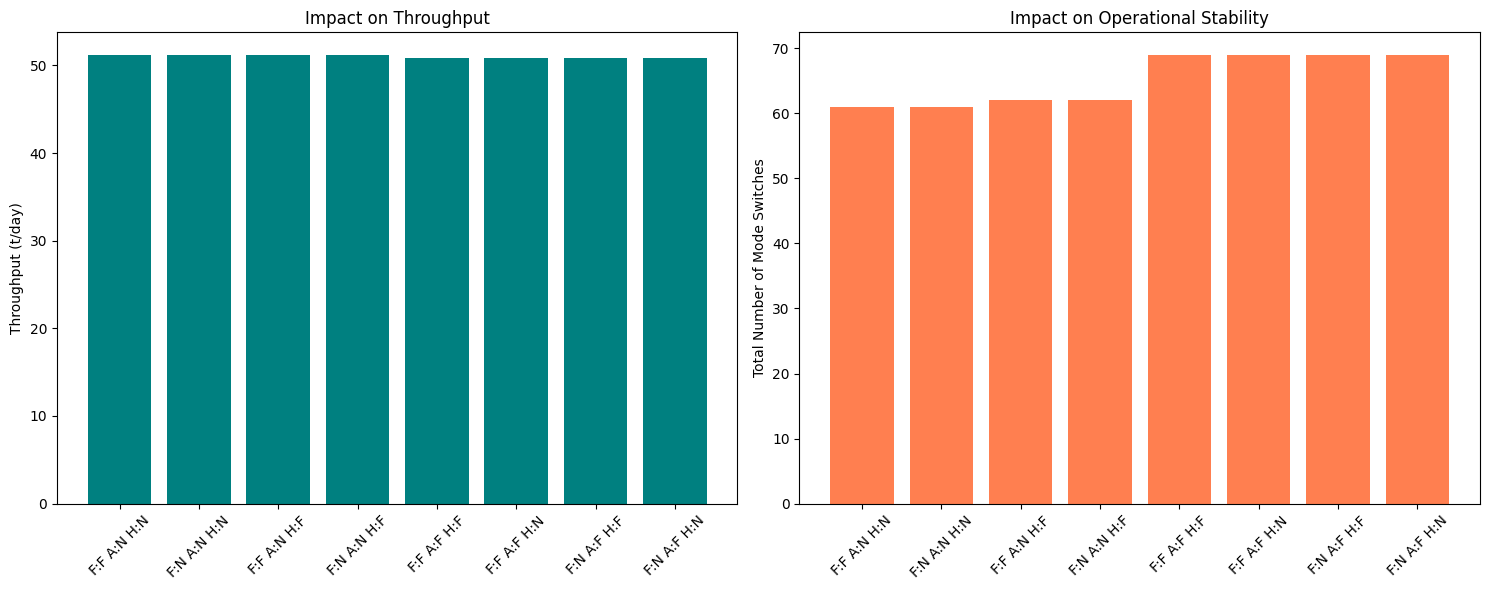

In [13]:
import matplotlib.pyplot as plt

# Create labels for the X-axis (e.g., "ON-OFF-ON")
labels = df_results.apply(
    lambda row: f"F:{row['Feed Control'][1]} A:{row['Adaptive Extraction'][1]} H:{row['Hysteresis'][1]}",
    axis=1,
)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# Plot 1: Throughput Comparison
ax1.bar(labels, df_results["Throughput (t/day)"], color="teal")
ax1.set_title("Impact on Throughput")
ax1.set_ylabel("Throughput (t/day)")
ax1.tick_params(axis="x", rotation=45)

# Plot 2: Stability (Mode Switches) Comparison
ax2.bar(labels, df_results["Mode Switches"], color="coral")
ax2.set_title("Impact on Operational Stability")
ax2.set_ylabel("Total Number of Mode Switches")
ax2.tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

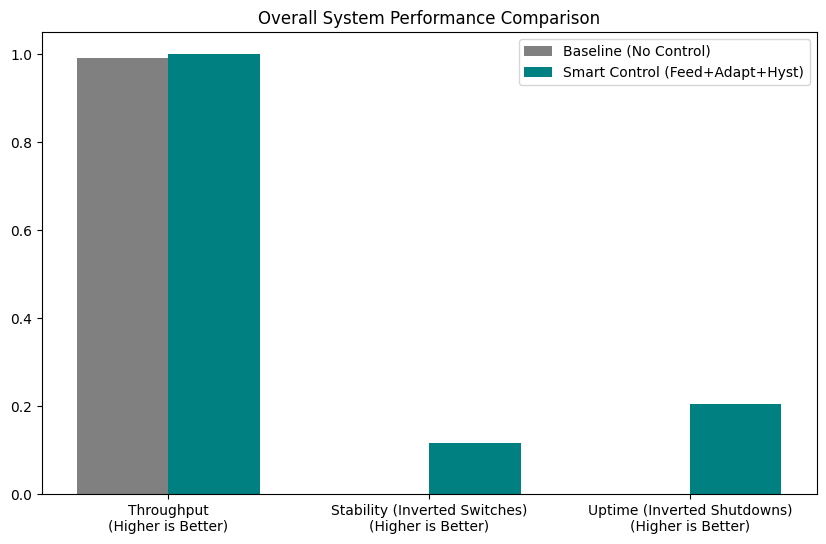

In [14]:
# Assuming you have the df_results from the ablation study
fig, ax = plt.subplots(figsize=(10, 6))

# We normalize the data so we can plot Throughput (thousands) next to Switches (tens)
df_normalized = df_results.copy()
for col in ["Throughput (t/day)", "Mode Switches", "Time in Shutdown (%)"]:
    # Normalize to a 0-1 scale based on the max value in that column
    df_normalized[col] = df_normalized[col] / df_normalized[col].max()

# Plot the optimal run (e.g., all 3 controllers ON) vs the Baseline (all 3 OFF)
baseline = df_normalized.iloc[-1]  # Assuming baseline sorted to bottom
optimal = df_normalized.iloc[0]  # Assuming best throughput sorted to top

x = np.arange(3)
width = 0.35

ax.bar(
    x - width / 2,
    [
        baseline["Throughput (t/day)"],
        1 - baseline["Mode Switches"],
        1 - baseline["Time in Shutdown (%)"],
    ],
    width,
    label="Baseline (No Control)",
    color="gray",
)
ax.bar(
    x + width / 2,
    [
        optimal["Throughput (t/day)"],
        1 - optimal["Mode Switches"],
        1 - optimal["Time in Shutdown (%)"],
    ],
    width,
    label="Smart Control (Feed+Adapt+Hyst)",
    color="teal",
)

ax.set_xticks(x)
ax.set_xticklabels(
    [
        "Throughput\n(Higher is Better)",
        "Stability (Inverted Switches)\n(Higher is Better)",
        "Uptime (Inverted Shutdowns)\n(Higher is Better)",
    ]
)
ax.set_title("Overall System Performance Comparison")
ax.legend()

plt.show()